In [1]:
! pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers 

In [ ]:
url = "1_boston_housing.csv"
data = pd.read_csv(url)

X = data.drop("MEDV", axis=1)
y = data["MEDV"]

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [8]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # Output layer (linear regression)
])

c:\Users\HP\anaconda4\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2,
    batch_size=16,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 588.3706 - mae: 22.2543 - val_loss: 495.8694 - val_mae: 20.5766
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 519.1350 - mae: 20.5776 - val_loss: 425.9089 - val_mae: 18.7819
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 429.6170 - mae: 18.2825 - val_loss: 328.4327 - val_mae: 16.0429
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 309.6701 - mae: 14.8683 - val_loss: 210.8708 - val_mae: 12.2144
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 188.1690 - mae: 10.7504 - val_loss: 115.0375 - val_mae: 8.0139
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 107.8244 - mae: 7.8196 - val_loss: 69.7822 - val_mae: 5.9197
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 73.3245 - mae: 6.5374 - val_loss: 50.5329 - val_mae: 5.0078
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 52.5305 - mae: 5.5114 - val_loss: 38.8409 - val_mae: 4.3557
Epoch 9/100
21/21 ━━━━━━━━━

In [12]:
loss, mae = model.evaluate(X_test, y_test)
print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 10.6574 - mae: 2.1657
Test Loss (MSE): 10.65744400024414
Test MAE: 2.1656742095947266


In [15]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


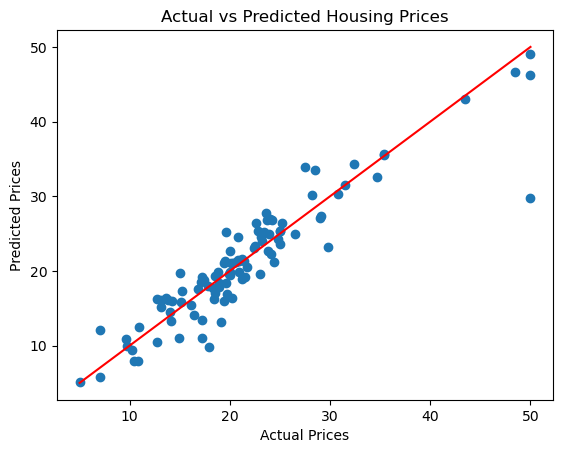

In [16]:
plt.scatter(y_test, y_pred.flatten())

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.show()

In [17]:
import seaborn as sns

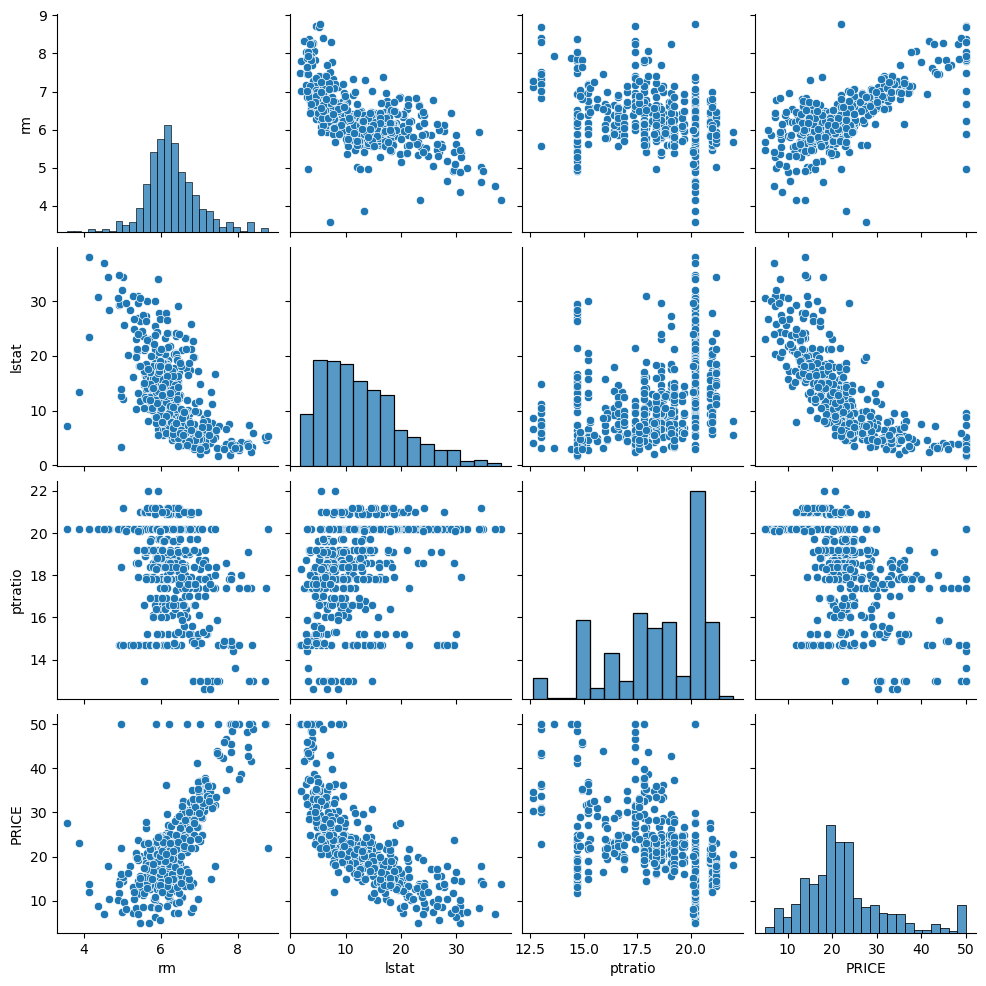

In [20]:
# Combine X and y into one DataFrame
data = X.copy()
data["PRICE"] = y

# Pairplot (limit columns for readability)
sns.pairplot(data[["rm", "lstat", "ptratio", "PRICE"]])
plt.show()

In [19]:
data.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'PRICE'],
      dtype='object')